# OrthoSAM examples

In [ ]:
import json
import os
import sys
from OrthoSAM.utility import load_config,create_dir_ifnotexist, prompt_fid,load_image, plot_tiling_with_overlap

**This example will process an entire directory containing several files. The data were taken from SediNet https://github.com/DigitalGrainSize/SediNet, because they provide reasonable sized images that take about 2 minutes per image.**

If you would like to process only a few images, we suggest downloading:
https://github.com/DigitalGrainSize/SediNet/blob/master/images/5_6.JPG
https://github.com/DigitalGrainSize/SediNet/blob/master/images/4.JPG
https://github.com/DigitalGrainSize/SediNet/blob/master/images/8.JPG

and place them into `data/SediNet/images`.

In the first step, we set parameters and create the list of files. If you set `id=None`, all files in the directory listed in 'DatasetName' will be processed. If you only want to process a single image, you either give the filename or the number of the file in the field 'fid'. *For this example, we only work with the first image (id=0).*

In [2]:
id=0 # Filename or the index after sorting by file name. If not known input None and all files will be listed with the index.
# For this example, we only work with the first image (id=0).

#main_para defines the parameters for the first layer
#it also serves as a template for the later layers.
main_para={'OutDIR': f'Sedinet/sedinet_{id}_up2_org',# where output will be stored relative to the MainOutDIR stored in config.json
    'DatasetName': 'SediNet/images',#where image is stored
    'fid': id, #Filename or the index after sorting by file name. If index is not known use None and all files will be listed with the index.
    'resolution(mm)': 1, #image resolution in mm/pixel
    'tile_size': 1024,
    'tile_overlap':200,
    'resample_factor': 1, #'Auto': auto select resample rate.
    'input_point_per_axis': 30,
    'dilation_size':5,
    'stability_t':0.85,
    'expected_min_size(sqmm)': 500,
    'min_radius': 0,
    'Calculate_stats': True, # True: calculate statistics. 
    'Discord_notification': False,# True: send discord when finished. If you wish to use this feature, please create a file name DWH.txt in the code directory and set the webhook.
    'Plotting': True# True: plot the results
    }

#para_list defines the parameters for the later layers
#each dictionary corresponds to one layer.
# The first layer is defined in main_para.
#the second layer is defined in para_list[0] and so on.
#main_para serves as a template for the later layers.
#and in para_list specify the parameters for each layer that need to be updated.
para_list=[
    {'resample_factor':0.5, #Using half of the resolution (half as many pixels) is a good starting point for a resampling factor.
    }
    ]

#parameters for preprocessing. Only create this list if you want to use preprocessing.
#preprocessing is optional.
pre_para_list=[{#'Gaussian': {'kernel size':3},
                #'CLAHE':{'clip limit':2},
                #'Resample': {'fxy':4},
                #'Buffering': {'crop size': crop_size}
            },{},{}]

You can verify the parameters by looking at the dictonaries

In [3]:
main_para

{'OutDIR': 'Sedinet/sedinet_0_up2_org',
 'DatasetName': 'SediNet/images',
 'fid': 0,
 'resolution(mm)': 1,
 'tile_size': 1024,
 'tile_overlap': 200,
 'resample_factor': 1,
 'input_point_per_axis': 30,
 'dilation_size': 5,
 'stability_t': 0.85,
 'expected_min_size(sqmm)': 500,
 'min_radius': 0,
 'Calculate_stats': True,
 'Discord_notification': False,
 'Plotting': True}

In [4]:
main_para['1st_resample_factor'] = main_para['resample_factor']
config = load_config()
main_para={**config,**main_para}
main_para['OutDIR'] = os.path.join(main_para.get('MainOutDIR'), main_para.get('OutDIR'))
if not os.path.exists(os.path.join(main_para.get('DataDIR'), main_para.get('DatasetName'))):
    print('Input directory does not exist. Exiting script.')
    sys.exit()

OutDIR=main_para.get('OutDIR')
create_dir_ifnotexist(OutDIR)
# if main_para.get('fid')==None:
#     main_para=prompt_fid(main_para)

/home/bodo/OrthoSAM/data/SediNet/images/4.JPG imported


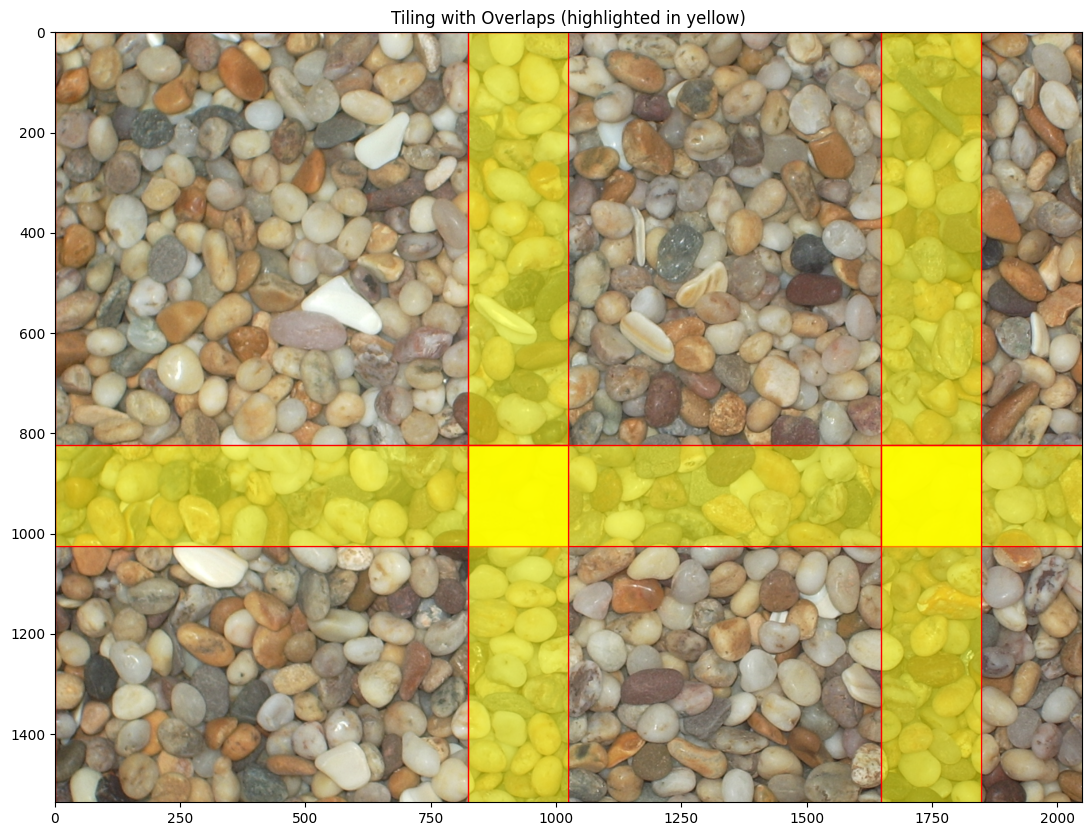

In [5]:
import matplotlib.pyplot as plt
DataDIR = main_para.get('DataDIR')
DSname = main_para.get('DatasetName')
fid = main_para.get('fid')
crop_size = main_para.get('tile_size')
overlap = main_para.get('tile_overlap')
image=load_image(DataDIR,DSname,fid)

plt.figure(figsize=(15,10))
plot_tiling_with_overlap(image, (crop_size,crop_size), overlap)

In [6]:
# Save init_para to a JSON file
para_list.insert(0, {})
pass_para_list = [dict(main_para, **para) for para in para_list]
with open(OutDIR+f'init_para.json', 'w') as json_file:
    json.dump(pass_para_list, json_file, indent=4)
with open(OutDIR+f'pre_para.json', 'w') as json_file:
    json.dump(pre_para_list, json_file, indent=4)

2025-08-19 12:52:56,041 - INFO - ---------------
2025-08-19 12:52:56,042 - INFO - Layer 0
2025-08-19 12:52:56,042 - INFO - 	Segment tiles
2025-08-19 12:52:56,043 - INFO - 	Loaded parameters from json
2025-08-19 12:52:56,043 - INFO - {'MODEL_TYPE': 'vit_h', 'CheckpointDIR': '/home/bodo/OrthoSAM/MetaSAM', 'DataDIR': '/home/bodo/OrthoSAM/data', 'BaseDIR': '/home/bodo/OrthoSAM', 'MainOutDIR': '/home/bodo/OrthoSAM/output', 'OutDIR': '/home/bodo/OrthoSAM/output/Sedinet/sedinet_0_up2_org', 'DatasetName': 'SediNet/images', 'fid': 0, 'resolution(mm)': 1, 'tile_size': 1024, 'tile_overlap': 200, 'resample_factor': 1, 'input_point_per_axis': 30, 'dilation_size': 5, 'stability_t': 0.85, 'expected_min_size(sqmm)': 500, 'min_radius': 0, 'Calculate_stats': True, 'Discord_notification': False, 'Plotting': True, '1st_resample_factor': 1}
2025-08-19 12:52:56,043 - INFO - 	Minimum expected size: 500.0 pixel
2025-08-19 12:52:56,044 - INFO - 	No pre_para found. Only applying resampling.
2025-08-19 12:52:56,

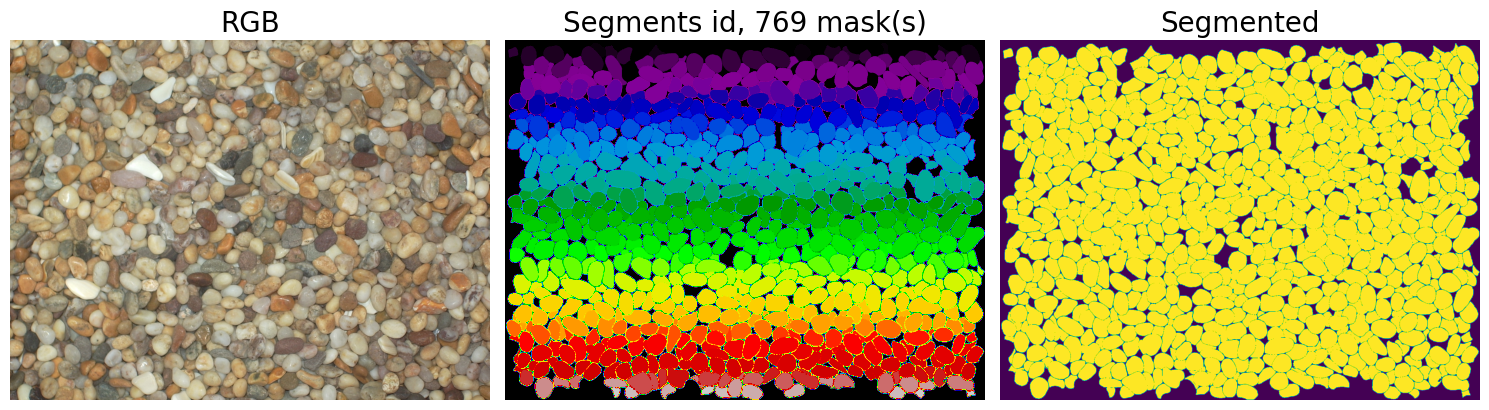

2025-08-19 12:55:37,564 - INFO - 	script took: 3.89 seconds
2025-08-19 12:55:37,566 - INFO - 	Merging completed.
2025-08-19 12:55:37,567 - INFO - ---------------
2025-08-19 12:55:37,567 - INFO - ---------------
2025-08-19 12:55:37,567 - INFO - Layer 1
2025-08-19 12:55:37,568 - INFO - 	Loaded parameters from /home/bodo/OrthoSAM/output/Sedinet/sedinet_0_up2_org
2025-08-19 12:55:37,568 - INFO - {'MODEL_TYPE': 'vit_h', 'CheckpointDIR': '/home/bodo/OrthoSAM/MetaSAM', 'DataDIR': '/home/bodo/OrthoSAM/data', 'BaseDIR': '/home/bodo/OrthoSAM', 'MainOutDIR': '/home/bodo/OrthoSAM/output', 'OutDIR': '/home/bodo/OrthoSAM/output/Sedinet/sedinet_0_up2_org', 'DatasetName': 'SediNet/images', 'fid': 0, 'resolution(mm)': 1, 'tile_size': 1024, 'tile_overlap': 200, 'resample_factor': 0.5, 'input_point_per_axis': 30, 'dilation_size': 5, 'stability_t': 0.85, 'expected_min_size(sqmm)': 500, 'min_radius': 0, 'Calculate_stats': True, 'Discord_notification': False, 'Plotting': True, '1st_resample_factor': 1}
2025

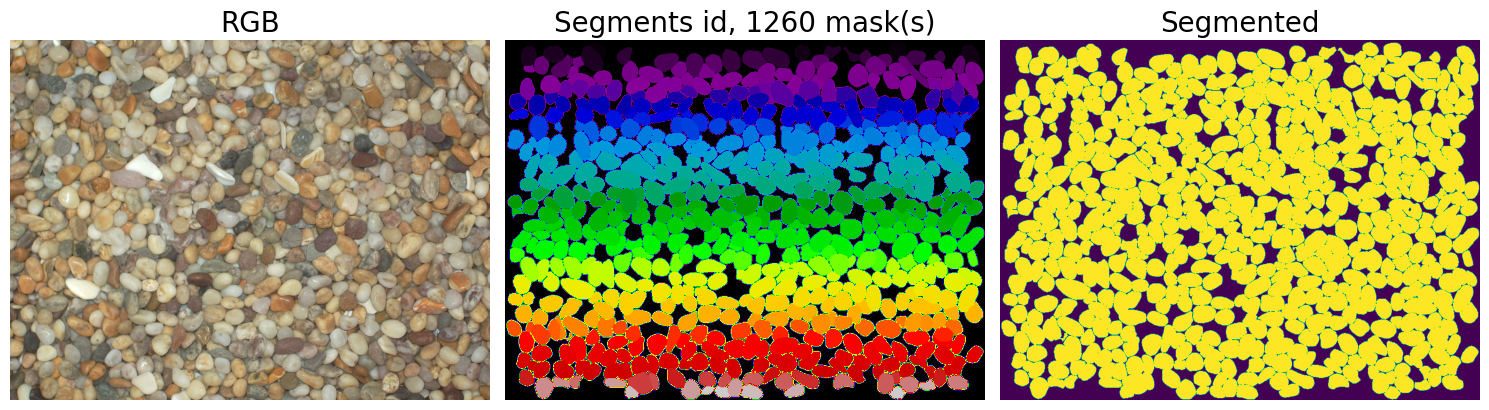

2025-08-19 12:56:16,664 - INFO - 	script took: 1.90 seconds
2025-08-19 12:56:16,665 - INFO - 	Merging completed.
2025-08-19 12:56:16,665 - INFO - ---------------
2025-08-19 12:56:16,709 - INFO - 
2025-08-19 12:56:16,710 - INFO -   0%|          | 0/580 [00:00<?, ?id/s]
2025-08-19 12:56:16,711 - INFO - 
2025-08-19 12:56:16,712 - INFO - 100%|##########| 580/580 [00:00<00:00, 428065.51id/s]
2025-08-19 12:56:16,723 - INFO - 	Layer 001 discovered 12 new mask(s)
2025-08-19 12:56:16,884 - INFO - 
2025-08-19 12:56:16,885 - INFO -   0%|          | 0/781 [00:00<?, ?it/s]
2025-08-19 12:56:16,986 - INFO - 
2025-08-19 12:56:16,987 - INFO -   8%|7         | 60/781 [00:00<00:01, 596.17it/s]
2025-08-19 12:56:17,102 - INFO - 
2025-08-19 12:56:17,103 - INFO -  15%|#5        | 120/781 [00:00<00:01, 546.07it/s]
2025-08-19 12:56:17,205 - INFO - 
2025-08-19 12:56:17,205 - INFO -  22%|##2       | 175/781 [00:00<00:01, 542.12it/s]
2025-08-19 12:56:17,308 - INFO - 
2025-08-19 12:56:17,308 - INFO -  29%|##9     

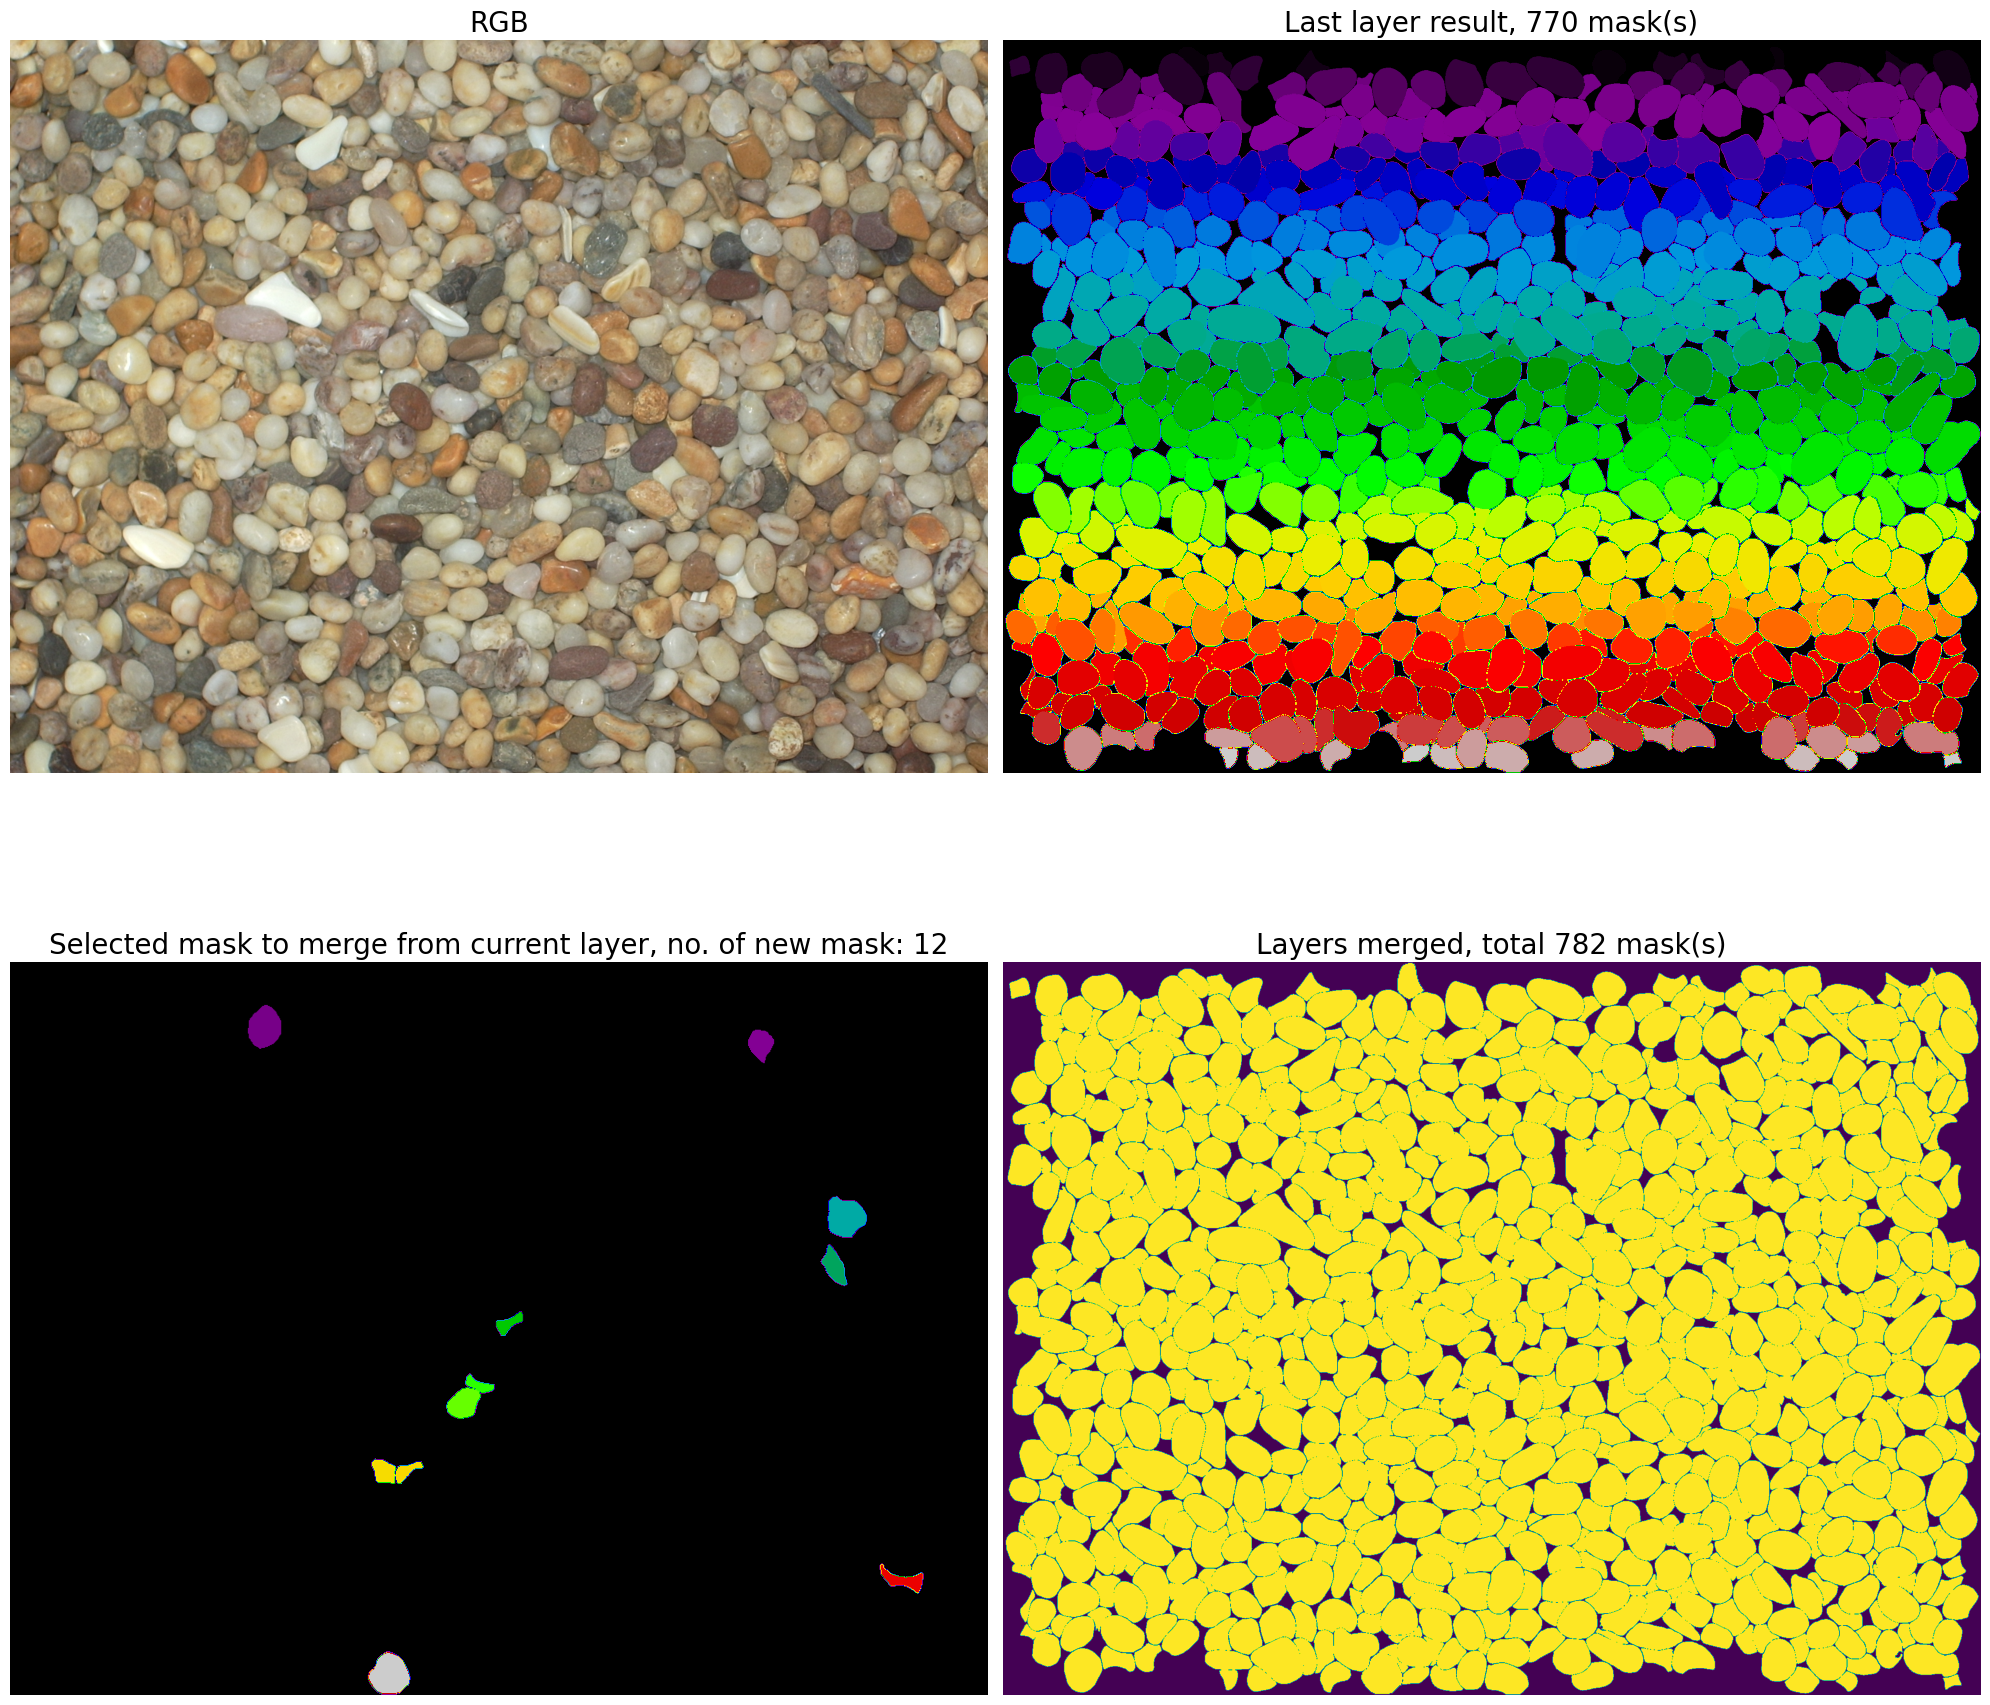

2025-08-19 12:56:21,121 - INFO - 	Saving id mask to /home/bodo/OrthoSAM/output/Sedinet/sedinet_0_up2_org/Merged/Merged_Layers_001.npy...
2025-08-19 12:56:21,130 - INFO - 	Saved
2025-08-19 12:56:21,131 - INFO - 	script took: 43.56 seconds
2025-08-19 12:56:21,131 - INFO - 	Output saved to /home/bodo/OrthoSAM/output/Sedinet/sedinet_0_up2_org
2025-08-19 12:56:21,132 - INFO - ---------------
2025-08-19 12:56:21,133 - INFO - Run took: 3.42 minutes
2025-08-19 12:56:21,133 - INFO - Calculating statistics...
2025-08-19 12:56:21,168 - INFO - /home/bodo/OrthoSAM/data/SediNet/images/4.JPG imported
2025-08-19 12:56:21,176 - INFO - /home/bodo/OrthoSAM/output/Sedinet/sedinet_0_up2_org/Merged/Merged_Layers_001.npy imported
2025-08-19 12:56:21,831 - INFO - Statistics saved to props.csv


In [7]:
from OrthoSAM import orthosam
orthosam(pass_para_list)

# Verify results and plot

Here we do some first-oder analysis of the output statistic data.

In [9]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

merged_results = pd.read_csv('/home/bodo/OrthoSAM/output/Sedinet/sedinet_1_up2_org/props.csv')

In [10]:
merged_results.head()

,label,centroid-0,centroid-1,axis_major_length,axis_minor_length,area,perimeter,IR,h,IRt,IRn,mean_R,mean_G,mean_B,median_R,median_G,median_B
0,1,51.447151,442.729894,110.446314,101.913859,8704.0,355.220346,0.866828,0.001614,0.997580,0.868931,182.592486,144.814453,96.842371,184.0,137.0,87.0
1,2,35.968719,1807.139785,51.760162,27.867058,1023.0,146.024387,0.602885,0.090037,0.870120,0.692876,113.728250,100.401760,80.397849,116.0,103.0,84.0
2,3,84.988431,169.490051,117.171667,94.528627,8644.0,355.303607,0.860450,0.011440,0.982926,0.875396,150.280773,134.250810,106.088385,153.0,136.0,106.0
3,4,56.149029,626.274890,51.854418,49.120602,1597.0,188.610173,0.564137,0.000733,0.998901,0.564758,163.501565,165.520351,144.077019,169.0,174.0,153.0
4,5,62.279221,1766.721320,71.525998,38.786690,1848.0,202.551299,0.566033,0.088082,0.872833,0.648501,91.094156,77.805736,59.996212,91.0,78.0,59.0


In [11]:
len(merged_results)

442

In [12]:
merged_results.describe()

,label,centroid-0,centroid-1,axis_major_length,axis_minor_length,area,perimeter,IR,h,IRt,IRn,mean_R,mean_G,mean_B,median_R,median_G,median_B
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,221.500000,786.041597,1012.600969,106.470554,65.067479,5804.959276,302.346265,0.671197,0.081587,0.885726,0.753411,148.257139,131.129128,106.777870,150.838235,133.018100,107.890271
std,127.738666,415.000577,573.879622,41.016822,29.258000,4194.355526,113.530987,0.147681,0.081048,0.107542,0.117000,29.185671,29.394126,28.956179,30.543441,30.804145,30.250838
min,1.000000,35.968719,38.673228,29.333604,15.718570,508.000000,90.426407,0.243048,0.000339,0.479977,0.395999,71.152174,59.214626,45.672677,72.000000,59.000000,49.000000
25%,111.250000,434.688099,498.125906,71.188313,37.888260,1679.000000,195.302561,0.575358,0.022208,0.829470,0.675969,127.287480,109.992815,85.322849,128.000000,111.000000,85.000000
50%,221.500000,779.727928,1020.047615,111.218052,67.377875,5512.000000,322.320851,0.677618,0.052565,0.922937,0.771841,152.782836,131.032854,103.785791,155.000000,132.000000,104.000000
75%,331.750000,1136.855178,1513.071959,132.142764,89.770782,8832.250000,384.236850,0.791907,0.119734,0.967009,0.855690,169.697846,151.522881,125.525150,174.000000,154.000000,127.000000
max,442.000000,1507.106518,2026.227397,246.792420,123.656208,21140.000000,607.553391,0.903637,0.412698,0.999491,0.917640,208.890175,211.735841,201.467844,212.000000,215.000000,204.000000


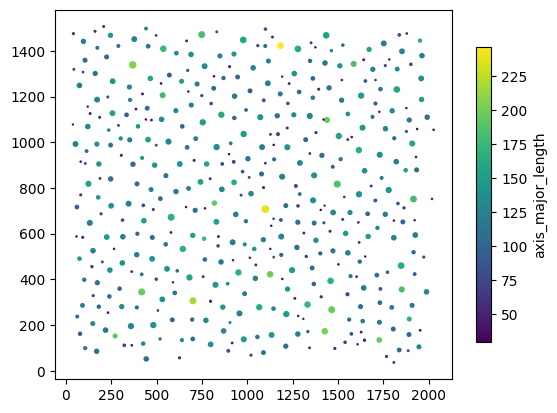

In [13]:
plt.scatter(merged_results['centroid-1'], merged_results['centroid-0'], c=merged_results['axis_major_length'], s=merged_results['area']/1000, cmap='viridis')
h = plt.colorbar(shrink=0.8)
h.set_label('axis_major_length')

## Loading labeled images

In [14]:
merged_img = np.load('/home/bodo/OrthoSAM/output/Sedinet/sedinet_1_up2_org/Merged/Merged_Layers_001.npy')

In [15]:
merged_img

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1536, 2048))

In [16]:
#convert to float and then set background to nan
merged_img = merged_img.astype(np.float32)

In [17]:
merged_img[merged_img == 0.0] = np.nan

In [18]:
len(np.unique(merged_img[~np.isnan(merged_img)]))

443

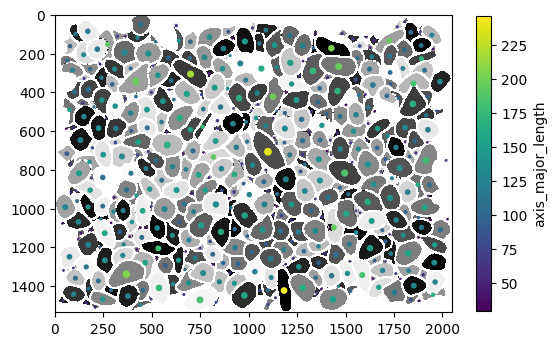

In [19]:
vals = np.linspace(0,1,256)
np.random.shuffle(vals)
cmap = plt.cm.colors.ListedColormap(plt.cm.gray(vals))
plt.imshow(merged_img, cmap=cmap)

plt.scatter(merged_results['centroid-1'], merged_results['centroid-0'], c=merged_results['axis_major_length'], s=merged_results['area']/1000, cmap='viridis')
h = plt.colorbar(shrink=0.8)
h.set_label('axis_major_length')

## Filter out pebbles with a roundness metric (isoperimetric ratio)

There are different ways to remove objects from the database that are no pebbles. You can do this manually by looking at the labelled images (see next point) - but this will be tidious when there are many pebbles. In this example, we rely on a roundness factor (see relevant publications cited in the main manuscript, including Cox, 1927; Pokhrel et al., 2024; Roussillon et al., 2009. The isoperimetric ratio is defined as the ratio of the area in 2D to its perimeter. This metric is dependent on the shape of the pebble, and hence a normalized isoperimetric ratio (IRn) has been developed that removes (partly) a shape dependence. The IRn is the isoperimetric ratio divided by a maximum theoretical isoperimetric ratio (IRt). 

In our output database, we provide all variants of the  isoperimetric ratio. For example, we can color each centroid by its IRn:

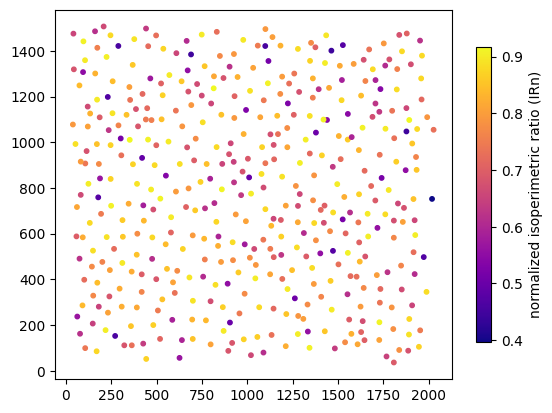

In [20]:
plt.scatter(merged_results['centroid-1'], merged_results['centroid-0'], c=merged_results['IRn'], s=10, cmap='plasma')
h = plt.colorbar(shrink=0.8)
h.set_label('normalized isoperimetric ratio (IRn)')

**We see that we have several pebbles with a very low IRn. Let's pick out all pebbles with an IRn below 0.45:**

In [21]:
merged_results[merged_results['IRn'] < 0.49]

,label,centroid-0,centroid-1,axis_major_length,axis_minor_length,area,perimeter,IR,h,IRt,IRn,mean_R,mean_G,mean_B,median_R,median_G,median_B
20,21,152.171720,271.498253,192.093611,78.577117,7157.0,508.315801,0.348076,0.175888,0.755419,0.460772,102.798100,92.889619,90.928182,97.0,86.0,84.0
132,133,497.412778,1971.922778,85.766382,41.061574,1800.0,241.965512,0.386345,0.124245,0.823387,0.469215,153.060000,127.907222,93.285000,157.0,131.0,95.0
134,135,524.667619,1471.665442,115.939855,83.609060,7347.0,450.433550,0.455049,0.026250,0.961073,0.473480,127.188104,110.821424,79.767932,128.0,111.0,80.0
216,217,758.933539,178.335388,140.341974,70.482967,5191.0,403.847763,0.399968,0.109800,0.842952,0.474485,163.780774,131.132730,99.289154,167.0,132.0,99.0
217,218,752.130636,2017.573410,63.643313,29.256126,865.0,184.509668,0.319292,0.137015,0.806295,0.395999,102.338728,87.972254,69.465896,108.0,96.0,77.0
307,308,1047.485448,1876.421746,102.911663,32.953979,1821.0,282.716775,0.286297,0.265126,0.644925,0.443923,96.173531,80.663372,66.244920,98.0,83.0,68.0
350,351,1198.523410,231.002795,85.025107,35.256905,1431.0,224.350288,0.357270,0.171200,0.761464,0.469188,144.264850,145.554857,136.972746,145.0,147.0,137.0
397,398,1384.661398,689.714938,136.129166,110.319928,8984.0,507.286363,0.438706,0.010967,0.983628,0.446008,182.935552,157.794301,115.034506,188.0,162.0,116.0
411,412,1421.530699,1098.576615,111.777851,59.610062,3746.0,344.977705,0.395545,0.092650,0.866501,0.456485,159.183663,151.690603,136.850240,162.0,153.0,137.0
413,414,1421.794581,289.148466,107.488337,60.997576,3617.0,334.107648,0.407179,0.076139,0.889508,0.457758,158.608792,121.388720,80.756152,164.0,123.0,80.0


In [22]:
merged_img_IRn045 = np.empty_like(merged_img)
merged_img_IRn045.fill(np.nan)
IRn045_df = merged_results[merged_results['IRn'] < 0.5]

for i in range(len(IRn045_df)):
    merged_img_IRn045[merged_img == IRn045_df.iloc[i]['label']] = IRn045_df.iloc[i]['label']

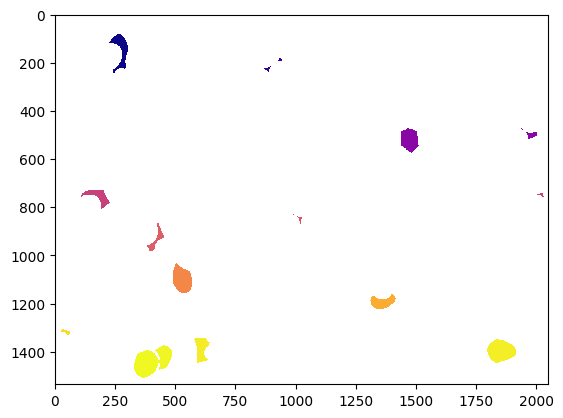

In [23]:
plt.imshow(merged_img_IRn045, cmap='plasma')


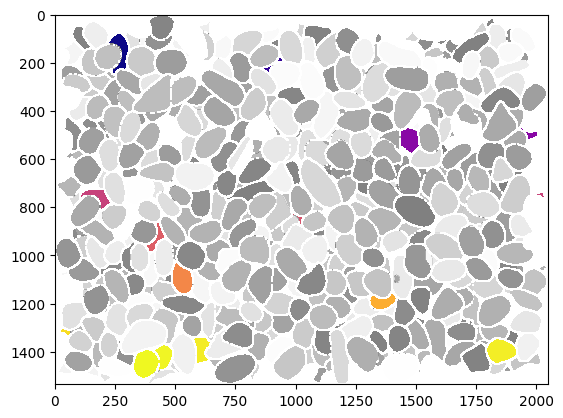

In [24]:
vals = np.linspace(0.5,1,256)
np.random.shuffle(vals)
cmap = plt.cm.colors.ListedColormap(plt.cm.gray(vals))
plt.imshow(merged_img, cmap=cmap)

plt.imshow(merged_img_IRn045, cmap='plasma')


## Plot size distribution

In [33]:
IRnabove05_df = merged_results[merged_results['IRn'] >= 0.5]
print(len(IRnabove05_df))
IRnabove05_df.head()

427


,label,centroid-0,centroid-1,axis_major_length,axis_minor_length,area,perimeter,IR,h,IRt,IRn,mean_R,mean_G,mean_B,median_R,median_G,median_B
0,1,51.447151,442.729894,110.446314,101.913859,8704.0,355.220346,0.866828,0.001614,0.997580,0.868931,182.592486,144.814453,96.842371,184.0,137.0,87.0
1,2,35.968719,1807.139785,51.760162,27.867058,1023.0,146.024387,0.602885,0.090037,0.870120,0.692876,113.728250,100.401760,80.397849,116.0,103.0,84.0
2,3,84.988431,169.490051,117.171667,94.528627,8644.0,355.303607,0.860450,0.011440,0.982926,0.875396,150.280773,134.250810,106.088385,153.0,136.0,106.0
3,4,56.149029,626.274890,51.854418,49.120602,1597.0,188.610173,0.564137,0.000733,0.998901,0.564758,163.501565,165.520351,144.077019,169.0,174.0,153.0
4,5,62.279221,1766.721320,71.525998,38.786690,1848.0,202.551299,0.566033,0.088082,0.872833,0.648501,91.094156,77.805736,59.996212,91.0,78.0,59.0


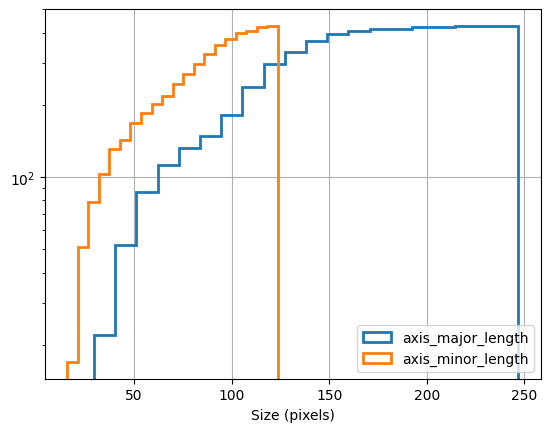

In [38]:
IRnabove05_df.axis_major_length.hist(bins = 20, log = True, cumulative=True, alpha=1, label='axis_major_length', histtype='step', linewidth=2) #density=True
IRnabove05_df.axis_minor_length.hist(bins = 20, log = True, cumulative=True, alpha=1, label='axis_minor_length', histtype='step', linewidth=2) #density=True
plt.xlabel('Size (pixels)')
plt.legend()